# Attention Map Demo

This notebook calls `analysis/plot_attention_map.py` to generate text from a local Hugging Face causal LM, rerun a forward pass with `output_attentions=True`, and plot the attention map from output tokens to input tokens.

Hosted API models usually do not expose attention tensors, so this works best with local/open-weight models such as `Qwen/Qwen3-4B`.

In [ ]:
# Install once if needed:
# %pip install -r analysis/requirements-attention.txt

In [ ]:
from pathlib import Path

analysis_dir = Path("analysis") if Path("analysis/plot_attention_map.py").exists() else Path(".")
script = analysis_dir / "plot_attention_map.py"
model_id = "Qwen/Qwen3-4B"
prompt = "Explain why traffic lights are timed differently at night."
out = analysis_dir / "qwen_output_to_input_attention.png"

In [ ]:
import subprocess
import sys

cmd = [
    sys.executable,
    str(script),
    "--model-id", model_id,
    "--prompt", prompt,
    "--chat",
    "--max-new-tokens", "80",
    "--layer", "-1",
    "--head", "mean",
    "--map", "output_to_input",
    "--out", str(out),
]
subprocess.run(cmd, check=True)

In [ ]:
from IPython.display import Image, display
display(Image(str(out)))

# My code

In [4]:
from pathlib import Path
import sys
from importlib import reload

project_root = Path.cwd()
if not (project_root / "utils").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import utils.utils as utils
reload(utils)

<module 'utils.utils' from 'h:\\Project\\traffic-hope-network\\utils\\utils.py'>

In [13]:
model_id = "Qwen/Qwen3-4B"
attn_implementation = "eager"
gen_kwargs = {
    'max_new_tokens': 1024,
    'temperature': 0.7,
    
}

In [6]:
model, tokenizer = utils.load_model_and_tokenizer(model_id, attn_implementation)

Loading checkpoint shards: 100%|██████████| 3/3 [00:06<00:00,  2.25s/it]
Some parameters are on the meta device because they were offloaded to the cpu.


In [12]:
prompt = r"Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May? Given the ground truth answer is $\boxed{72}$"
prompt = utils.build_prompt(tokenizer, "", prompt, False, True)

In [ ]:
full_ids, generated_text = utils.generate_and_concate(model, tokenizer, prompt, **gen_kwargs)

In [ ]:
attn_weights, full_outputs = utils.get_attention_weights(model, full_ids)

In [ ]:
from importlib import reload
reload(utils)

prompt_len = tokenizer(prompt, return_tensors="pt")["input_ids"].shape[1]
fig, axes = utils.plot_all_layer_head_attention(
    attn_weights,
    prompt_len=prompt_len,
    tokenizer=tokenizer,
    sequence_ids=full_ids,
    out_path=None,
    dpi=180,
    panel_size=3.2,
    label_fontsize=3,
    tight=True,
)

fig

Plotting layer 1/36...
Plotting layer 2/36...
Plotting layer 3/36...
Plotting layer 4/36...
Plotting layer 5/36...
Plotting layer 6/36...
Plotting layer 7/36...
Plotting layer 8/36...
Plotting layer 9/36...
Plotting layer 10/36...
Plotting layer 11/36...
Plotting layer 12/36...
Plotting layer 13/36...
Plotting layer 14/36...
Plotting layer 15/36...
Plotting layer 16/36...
Plotting layer 17/36...
Plotting layer 18/36...
Plotting layer 19/36...
Plotting layer 20/36...
Plotting layer 21/36...
Plotting layer 22/36...
Plotting layer 23/36...
Plotting layer 24/36...
Plotting layer 25/36...
Plotting layer 26/36...
Plotting layer 27/36...
Plotting layer 28/36...
Plotting layer 29/36...
Plotting layer 30/36...
Plotting layer 31/36...
Plotting layer 32/36...
Plotting layer 33/36...
Plotting layer 34/36...
Plotting layer 35/36...
Plotting layer 36/36...


torch.Size([80, 209])

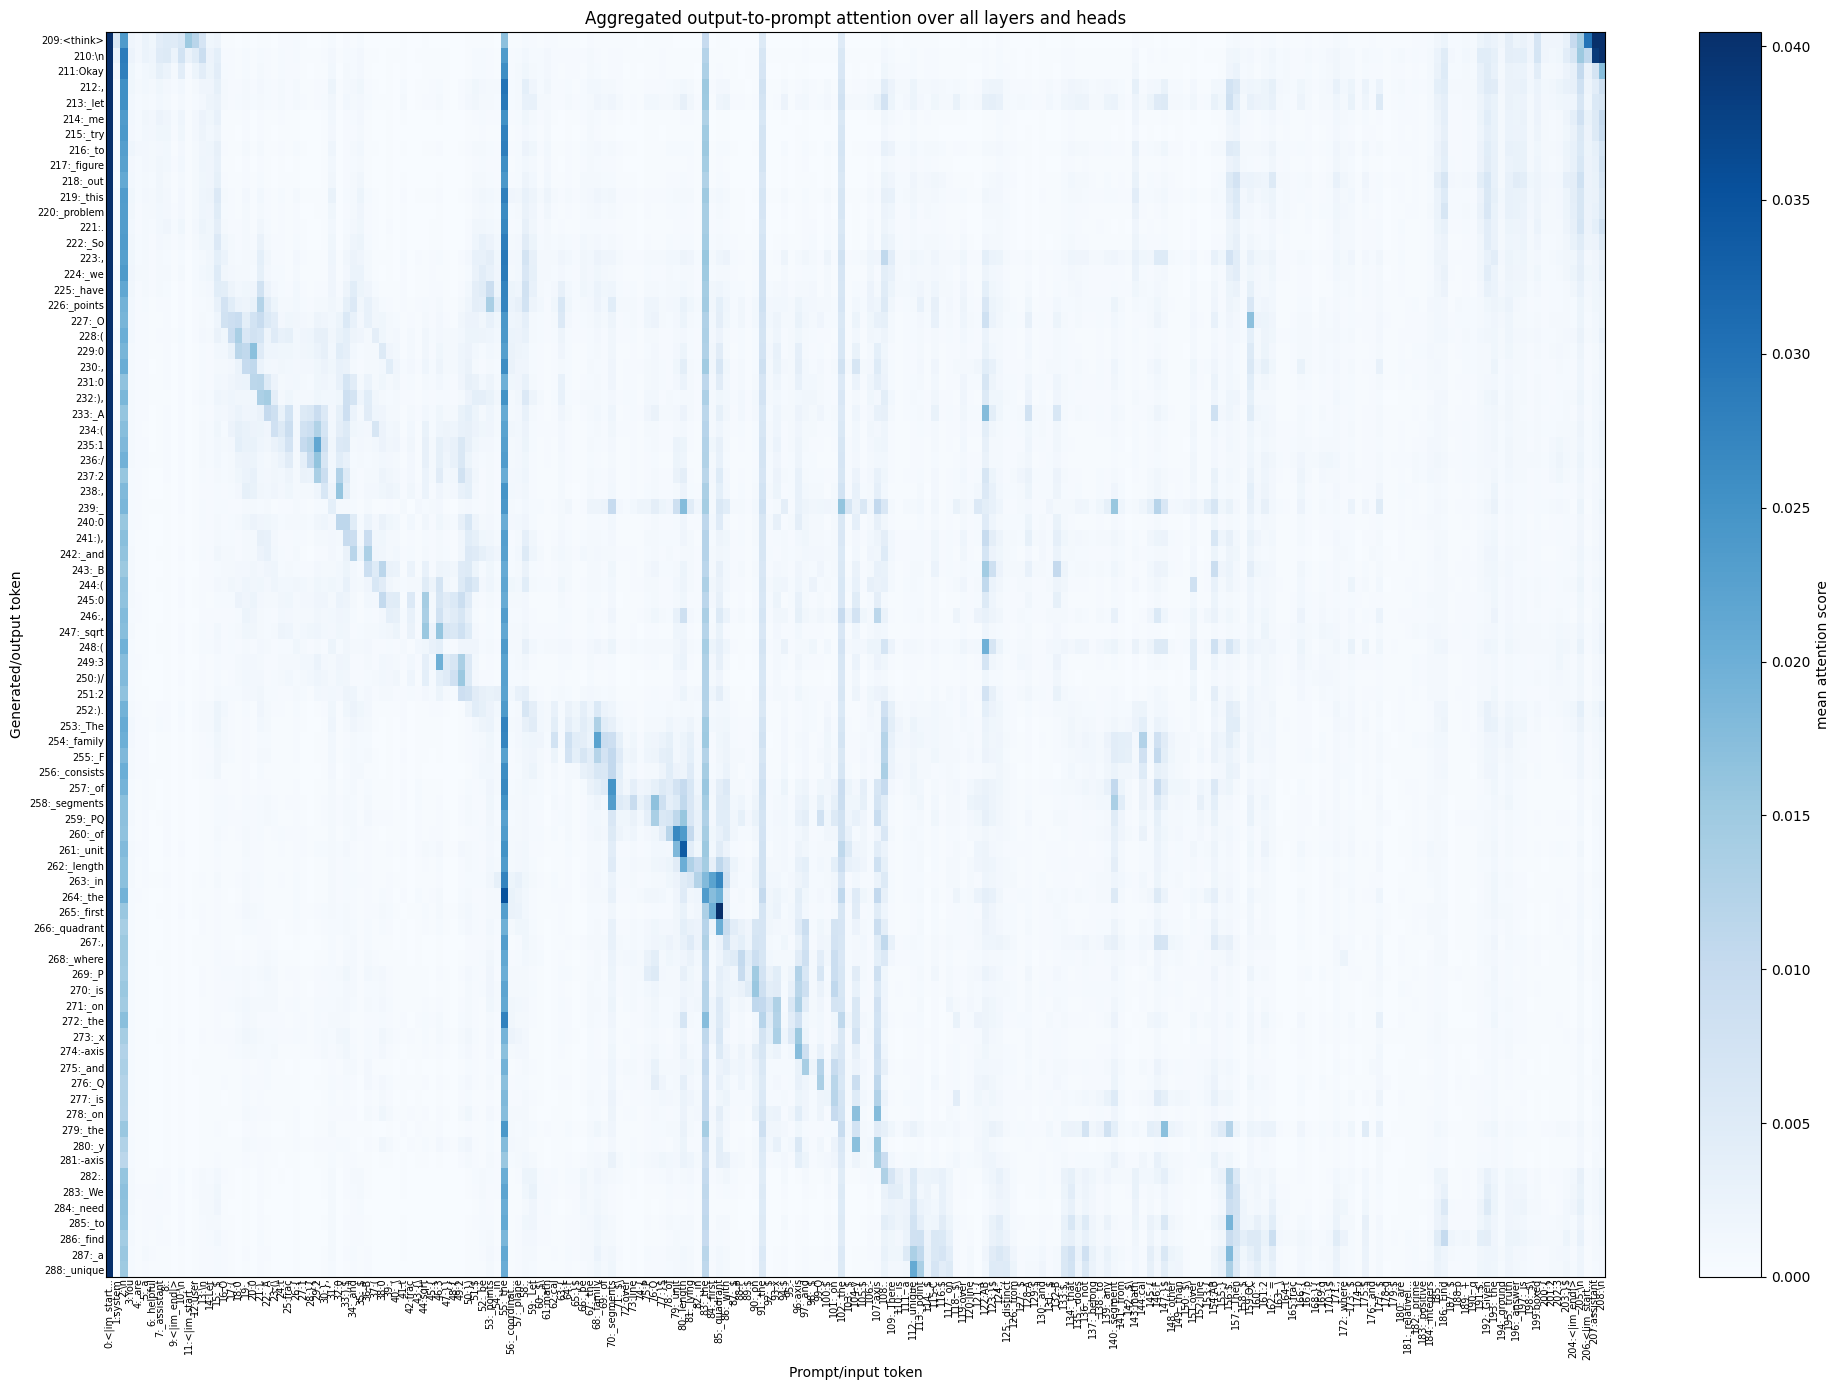

In [ ]:
from importlib import reload
reload(utils)

prompt_len = tokenizer(prompt, return_tensors="pt")["input_ids"].shape[1]
agg_attn_map, fig, ax = utils.plot_aggregated_attention(
    attn_weights,
    prompt_len=prompt_len,
    tokenizer=tokenizer,
    sequence_ids=full_ids,
    out_path=project_root / "analysis" / "aggregated_output_to_prompt_attention.png",
    dpi=180,
    figsize=(20, 14),
    label_fontsize=7,
)

agg_attn_map.shape